# Часть 1: Работа с CLIP

В рамках данного проекта была использована предобученная модель CLIP для сопоставления изображений и текстов на основе косинусного сходства эмбеддингов. 

Цель — исследовать, насколько точно модель «понимает» визуальные сцены и соответствующие описания, а также выявить, какие визуальные признаки определяют это соответствие при помощи методов интерпретации Grad-CAM и Grad-CAM++. Использовался набор из 10 пар изображений и описаний (по 3 на каждое изображение), взятых из датасета по ссылке https://www.kaggle.com/datasets/hsankesara/flickr-image-dataset. и доработанных вручную (некоторые описания).

Изображения, которые я использовала, можно найти по ссылке: https://drive.google.com/drive/folders/1J1HbkbtS2cYoDDQVAloZsVanclzYQE2k?usp=drive_link

In [1]:
#!pip install gradio
#!pip install dash plotly torchvision
#!pip install transformers
#!pip install ftfy open_clip_torch
#!pip install ftfy regex tqdm
#!pip install git+https://github.com/openai/CLIP.git
#!pip install torchcam timm

In [2]:
import torch
import clip
from PIL import Image
import glob
import os
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

/root/venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
# Загрузка модели CLIP и устройство
device = "cuda" if torch.cuda.is_available() else "cpu"
model, preprocess = clip.load("ViT-B/32", device=device)

In [4]:
# Загрузка изображений
image_paths = sorted(glob.glob("images/*.jpg"))
images = [preprocess(Image.open(p)).unsqueeze(0).to(device) for p in image_paths]
image_input = torch.cat(images)

In [5]:
# Сопоставим текстовые описания с изображениями
text_descriptions = [
    "A child playing in the playground",
    "A little girl in pink climbs a rope bridge at the park",
    "The small child climbs on a red ropes on a playground",

    "A person standing in the garden",
    "Two men in green shirts are standing in a yard",
    "Two young guys with shaggy hair look at their hands while hanging out in the yard",

    "A baby laying on a back",
    "A little baby dressed in green and yellow wearing a bib cries",
    "Baby wears green frog big and makes grotesque face",

    "A person riding a bicycle in winter",
    "A bike-rider in the winter landscape",
    "A young boy rides a bike down a snow covered road .",

    "A black and white bird eating seeds out of someone 's hand",
    "Black and white bird standing on hand of someone holding sunflower seeds",
    "The small bird is clinging to a finger of the hand holding the seeds",

    "Coconuts on the counter of a street trader",
    "A trader selling coconuts on the street",
    "A street vendor is sitting on a chair, next to him is a counter with a lot of coconuts on cardboard boxes",

    "The large brown and white dog shakes off water",
    "A furry dog attempts to dry itself by shaking the water off its coat",
    "A brown and white dog stands outside while it snows",
   
    "Five Asian doctors in green hospital scrubs and masks having a discussion over what appears to be an ongoing operation",
    "A five person surgical team is about to perform an operation in a hospital",
    "Doctors wearing green scrubs are performing surgery on a patient",

    "A city landscape with a skyscraper in the center",
    "A skyscraper and two buildings on the sides with a head of the person in the center of the photo",
    "There is a skyscraper in the distance with a man walking in front of the camera",

    "A woman in a green skirt singing on stage",
    "A young woman holds her green skirt and sings",
    "A redhead woman holds her green skird widely and performs on stage"
]

/tmp/ipykernel_215/1769272334.py:30: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all axes decorations.
  plt.tight_layout()


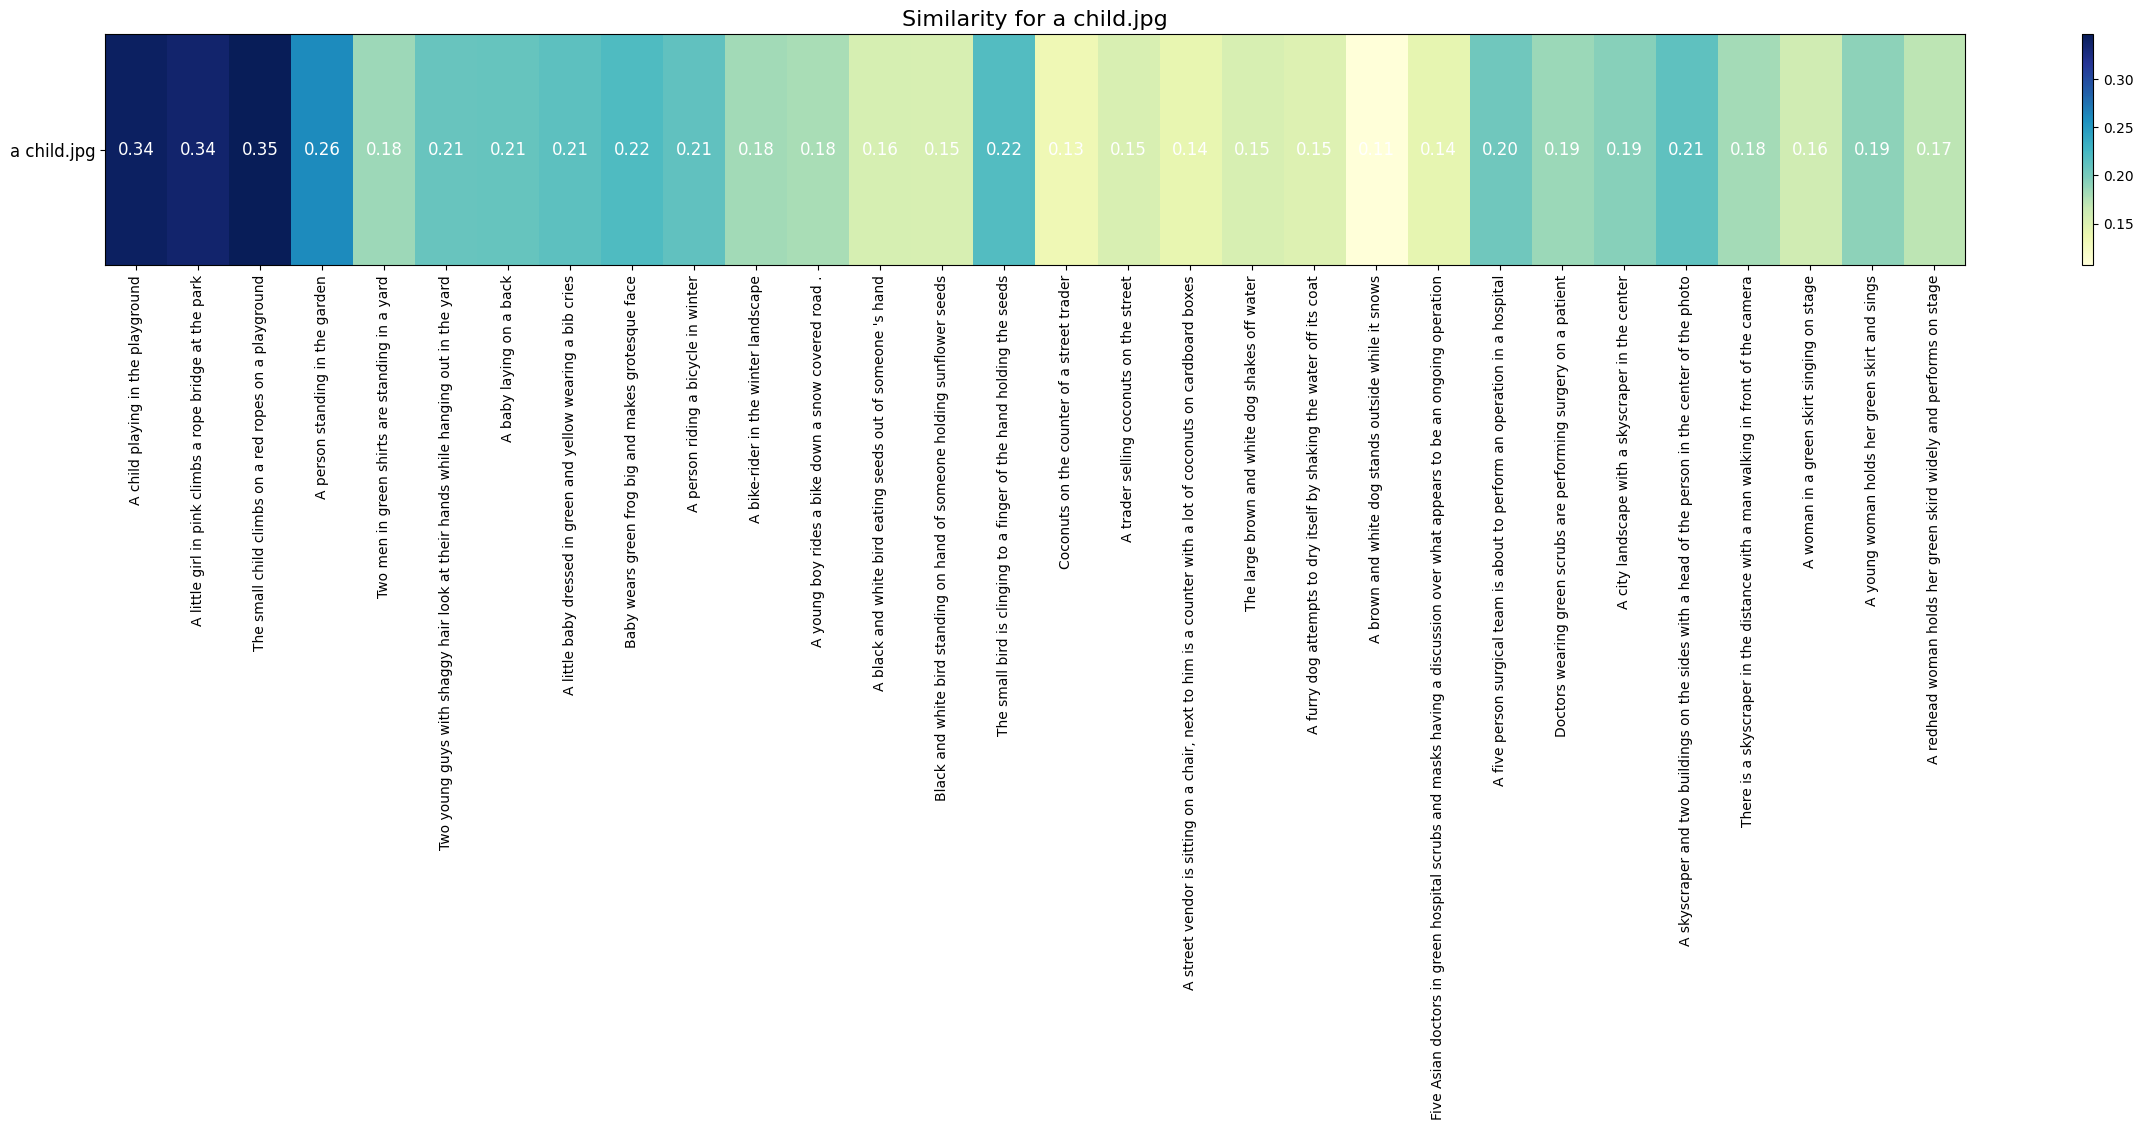

/tmp/ipykernel_215/1769272334.py:30: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all axes decorations.
  plt.tight_layout()


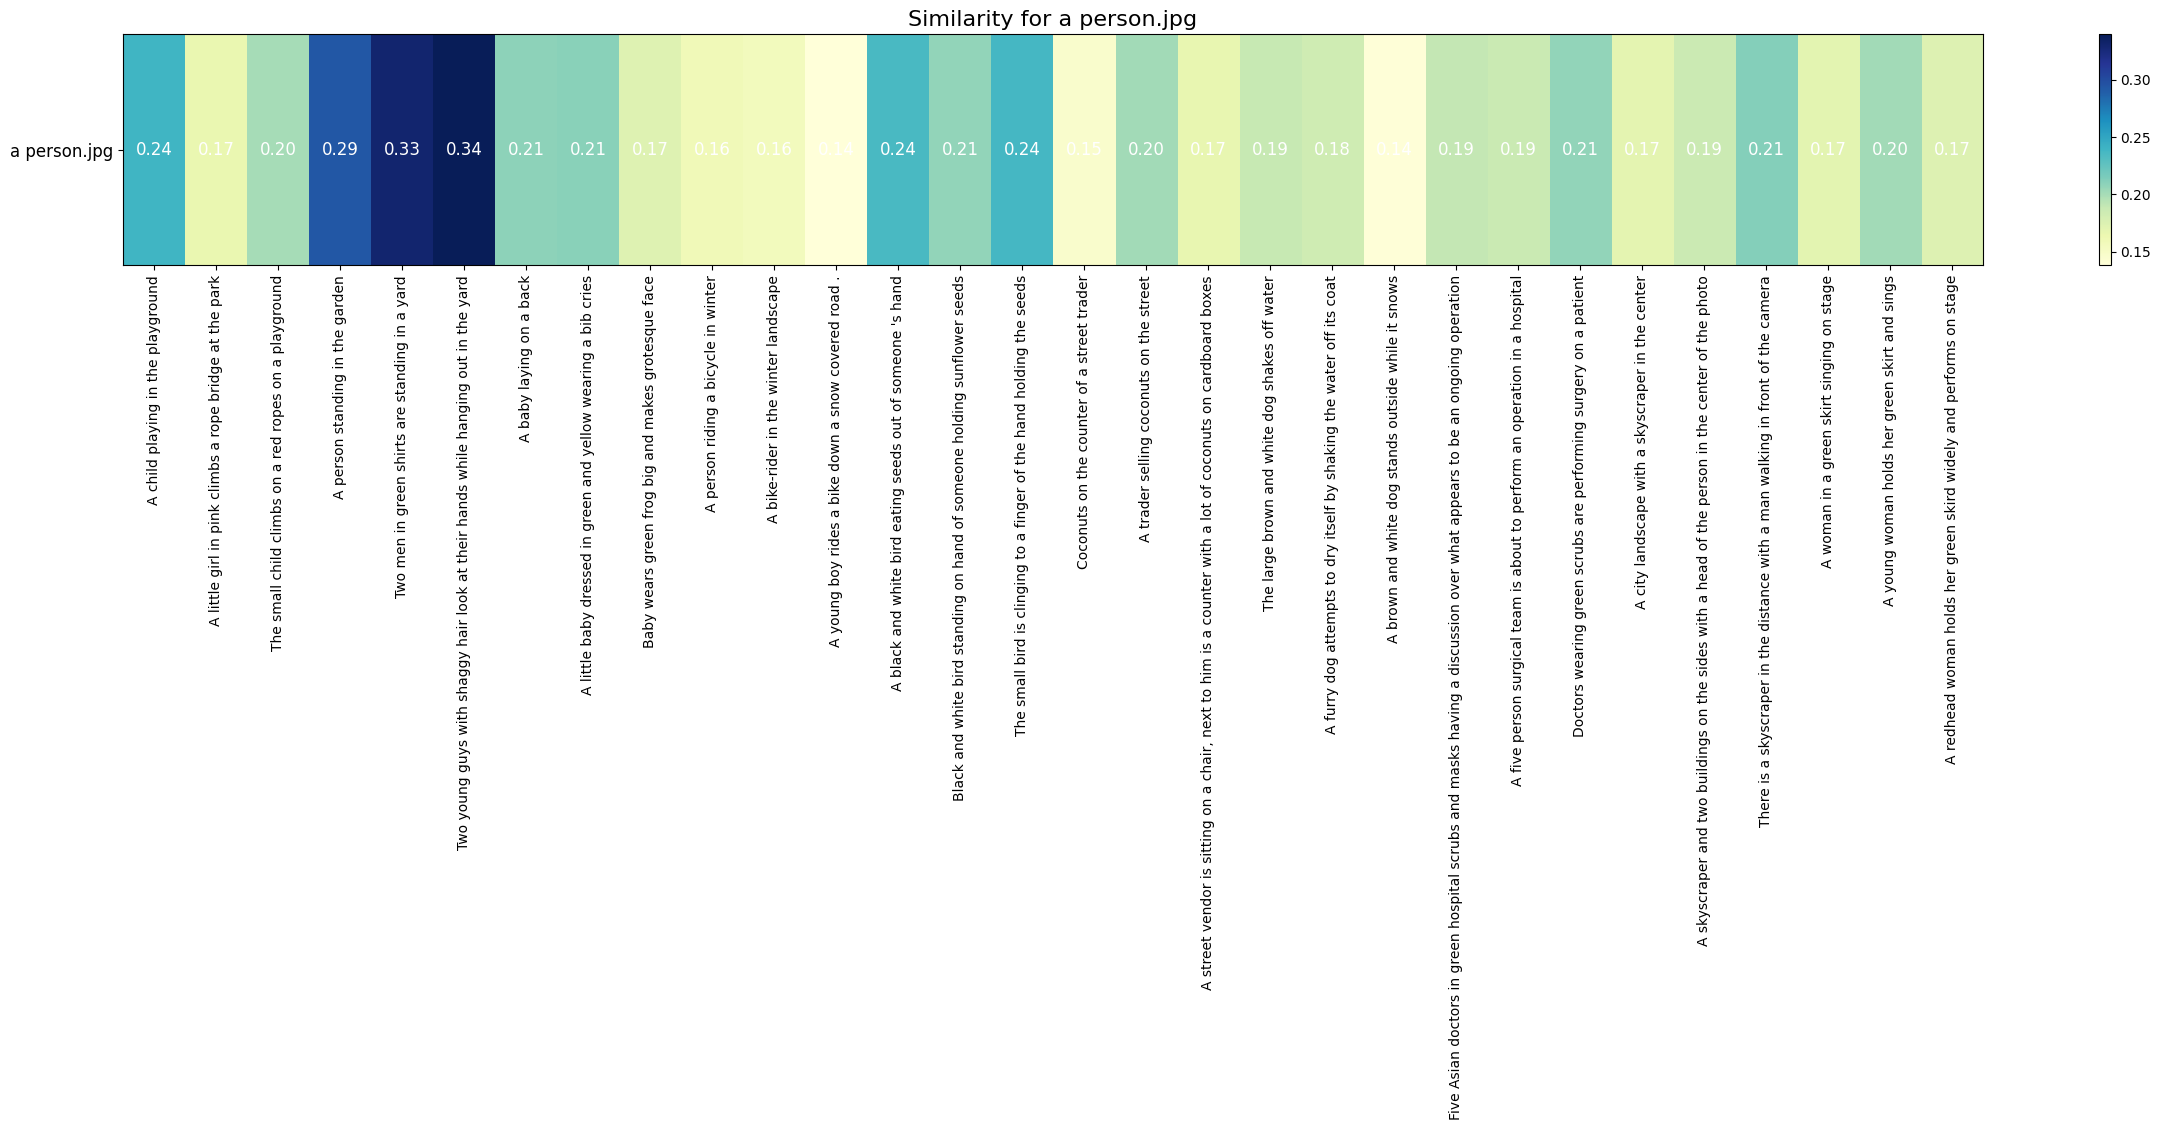

/tmp/ipykernel_215/1769272334.py:30: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all axes decorations.
  plt.tight_layout()


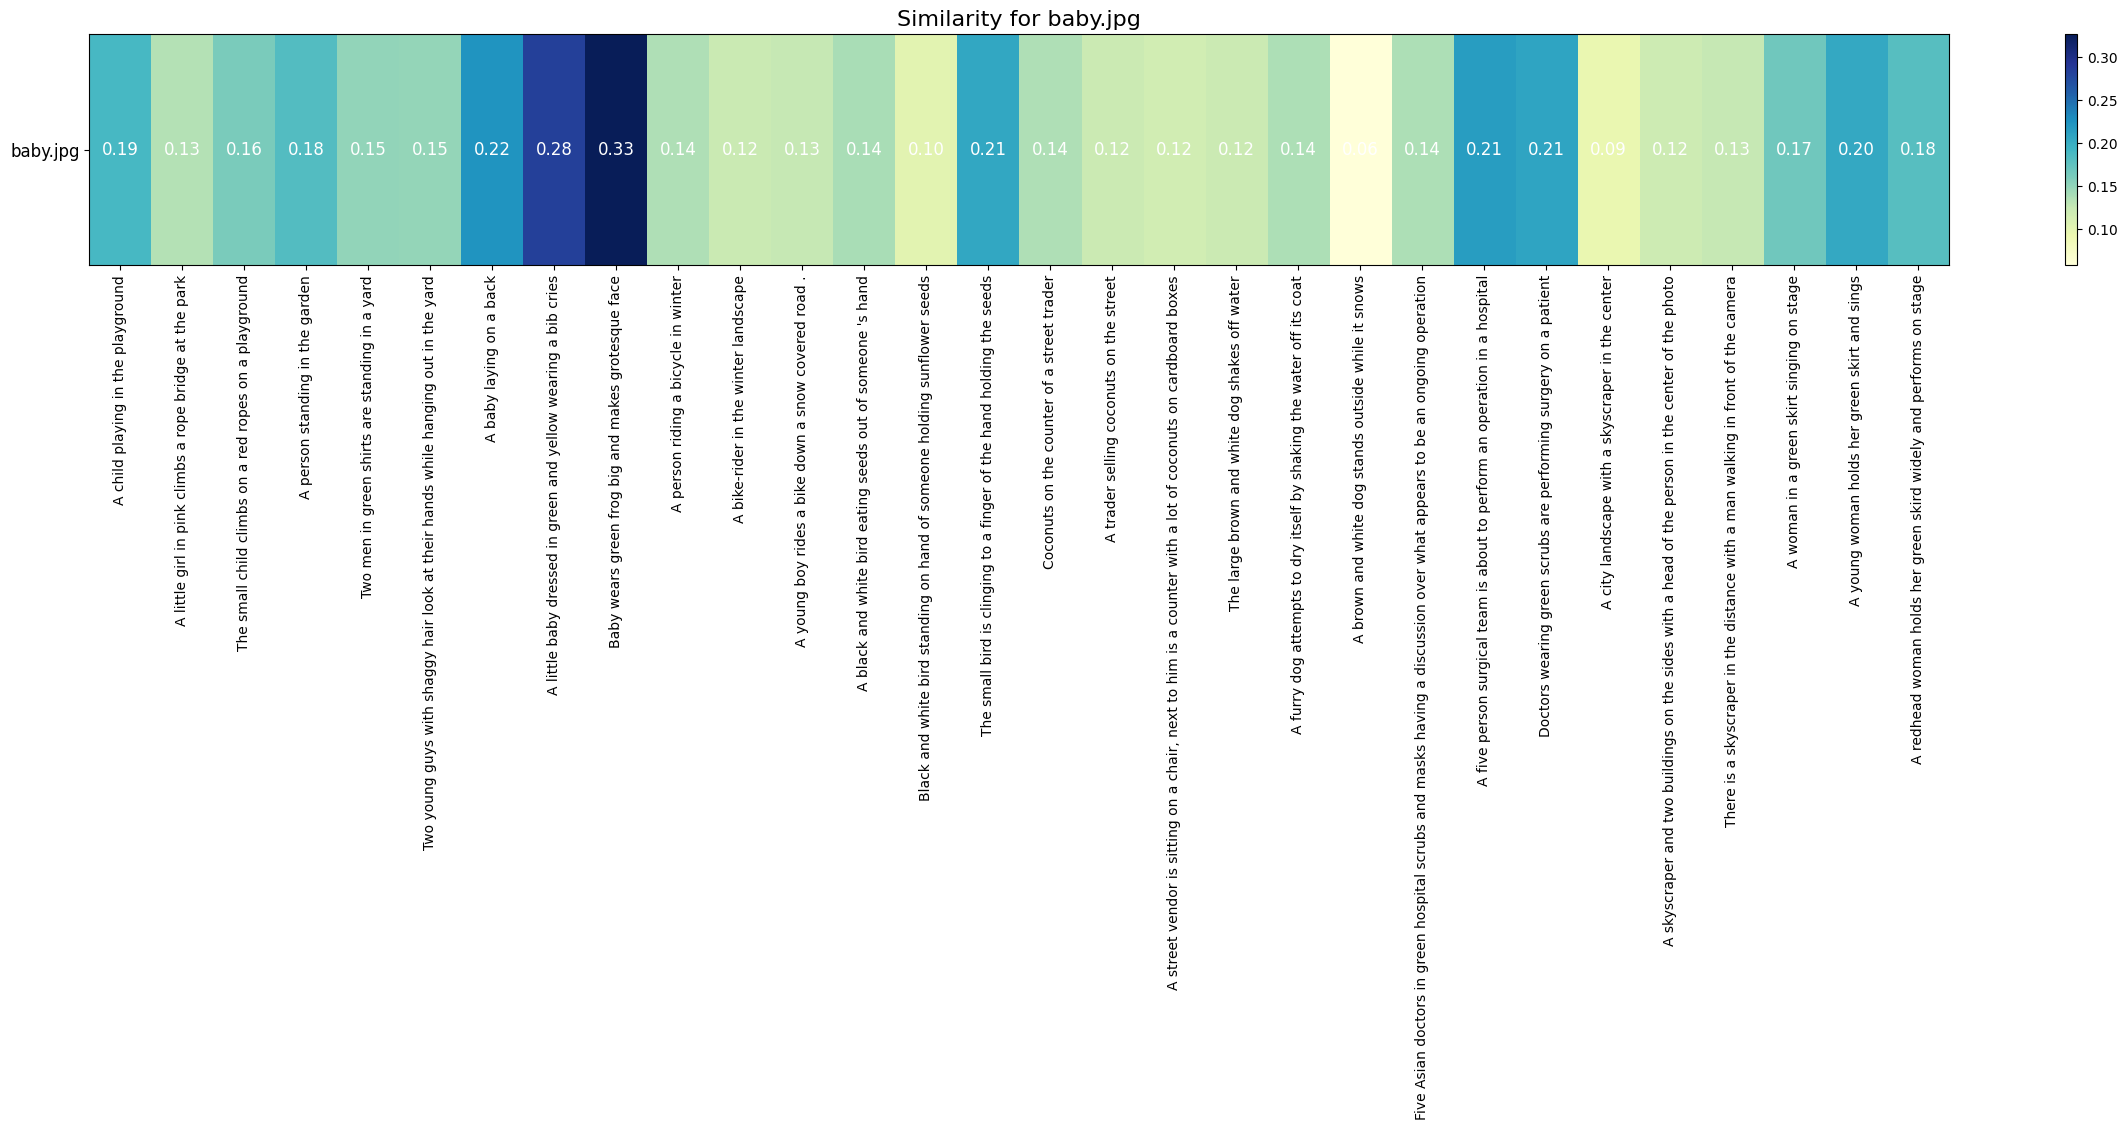

/tmp/ipykernel_215/1769272334.py:30: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all axes decorations.
  plt.tight_layout()


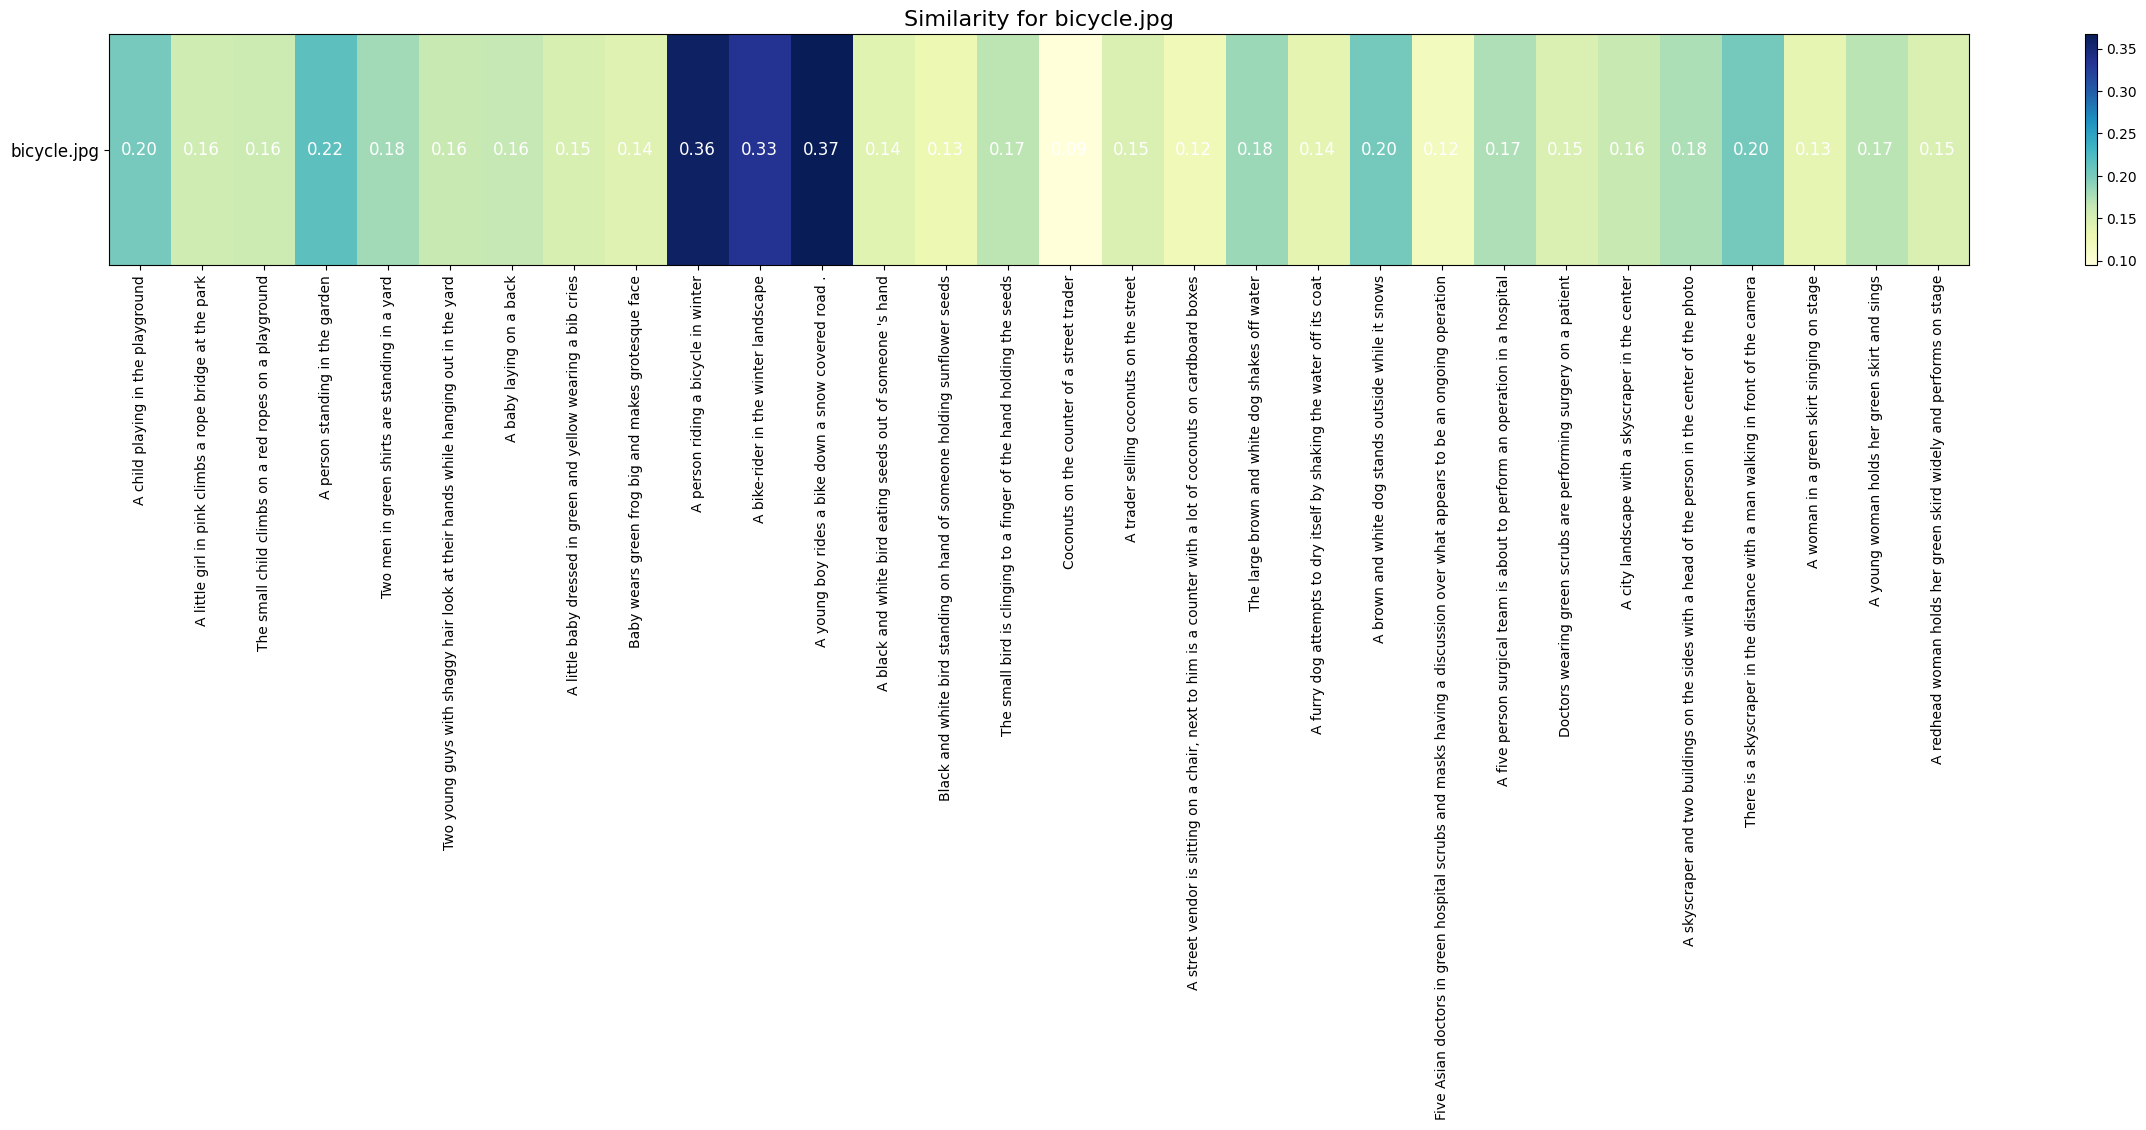

/tmp/ipykernel_215/1769272334.py:30: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all axes decorations.
  plt.tight_layout()


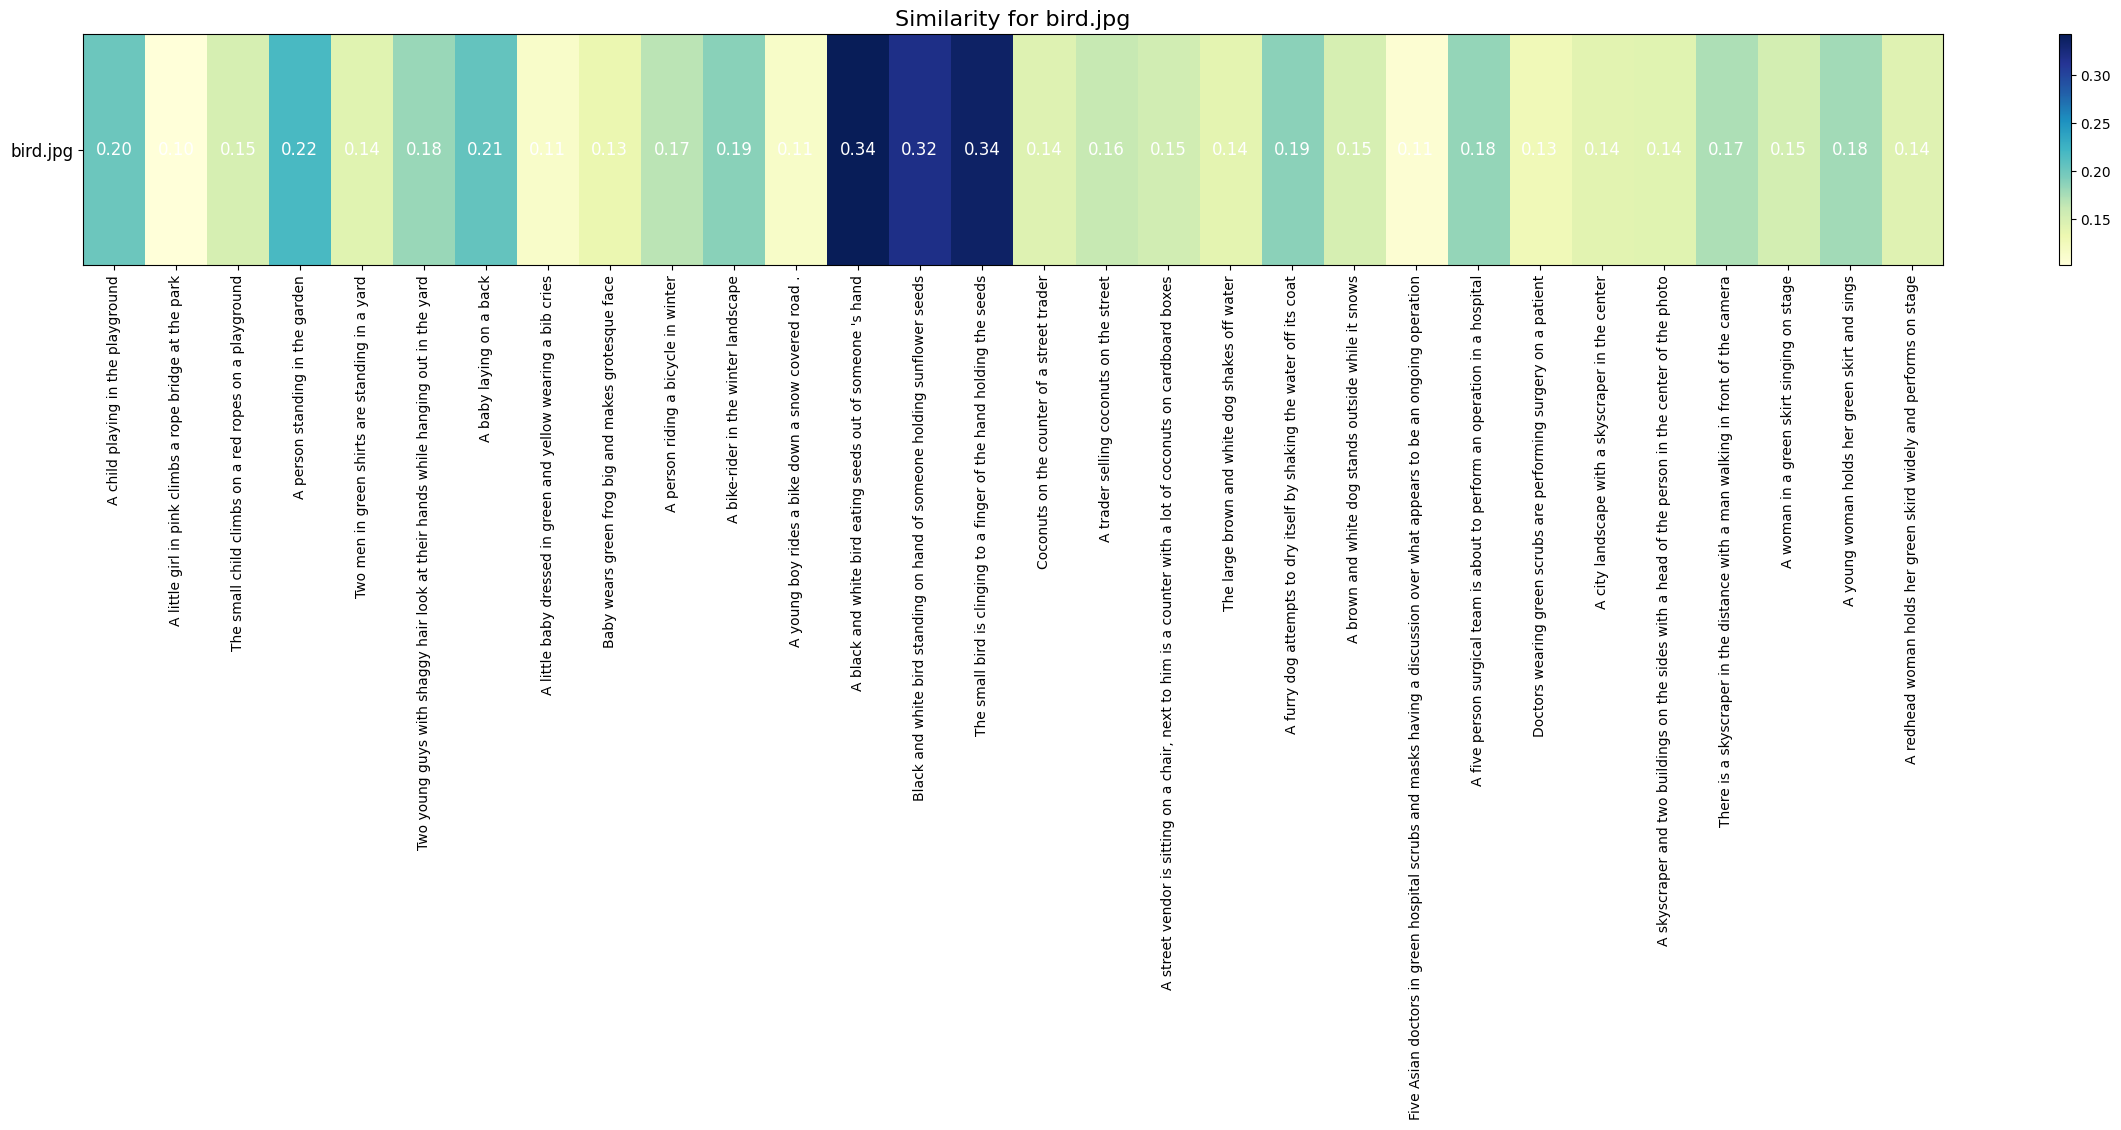

/tmp/ipykernel_215/1769272334.py:30: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all axes decorations.
  plt.tight_layout()


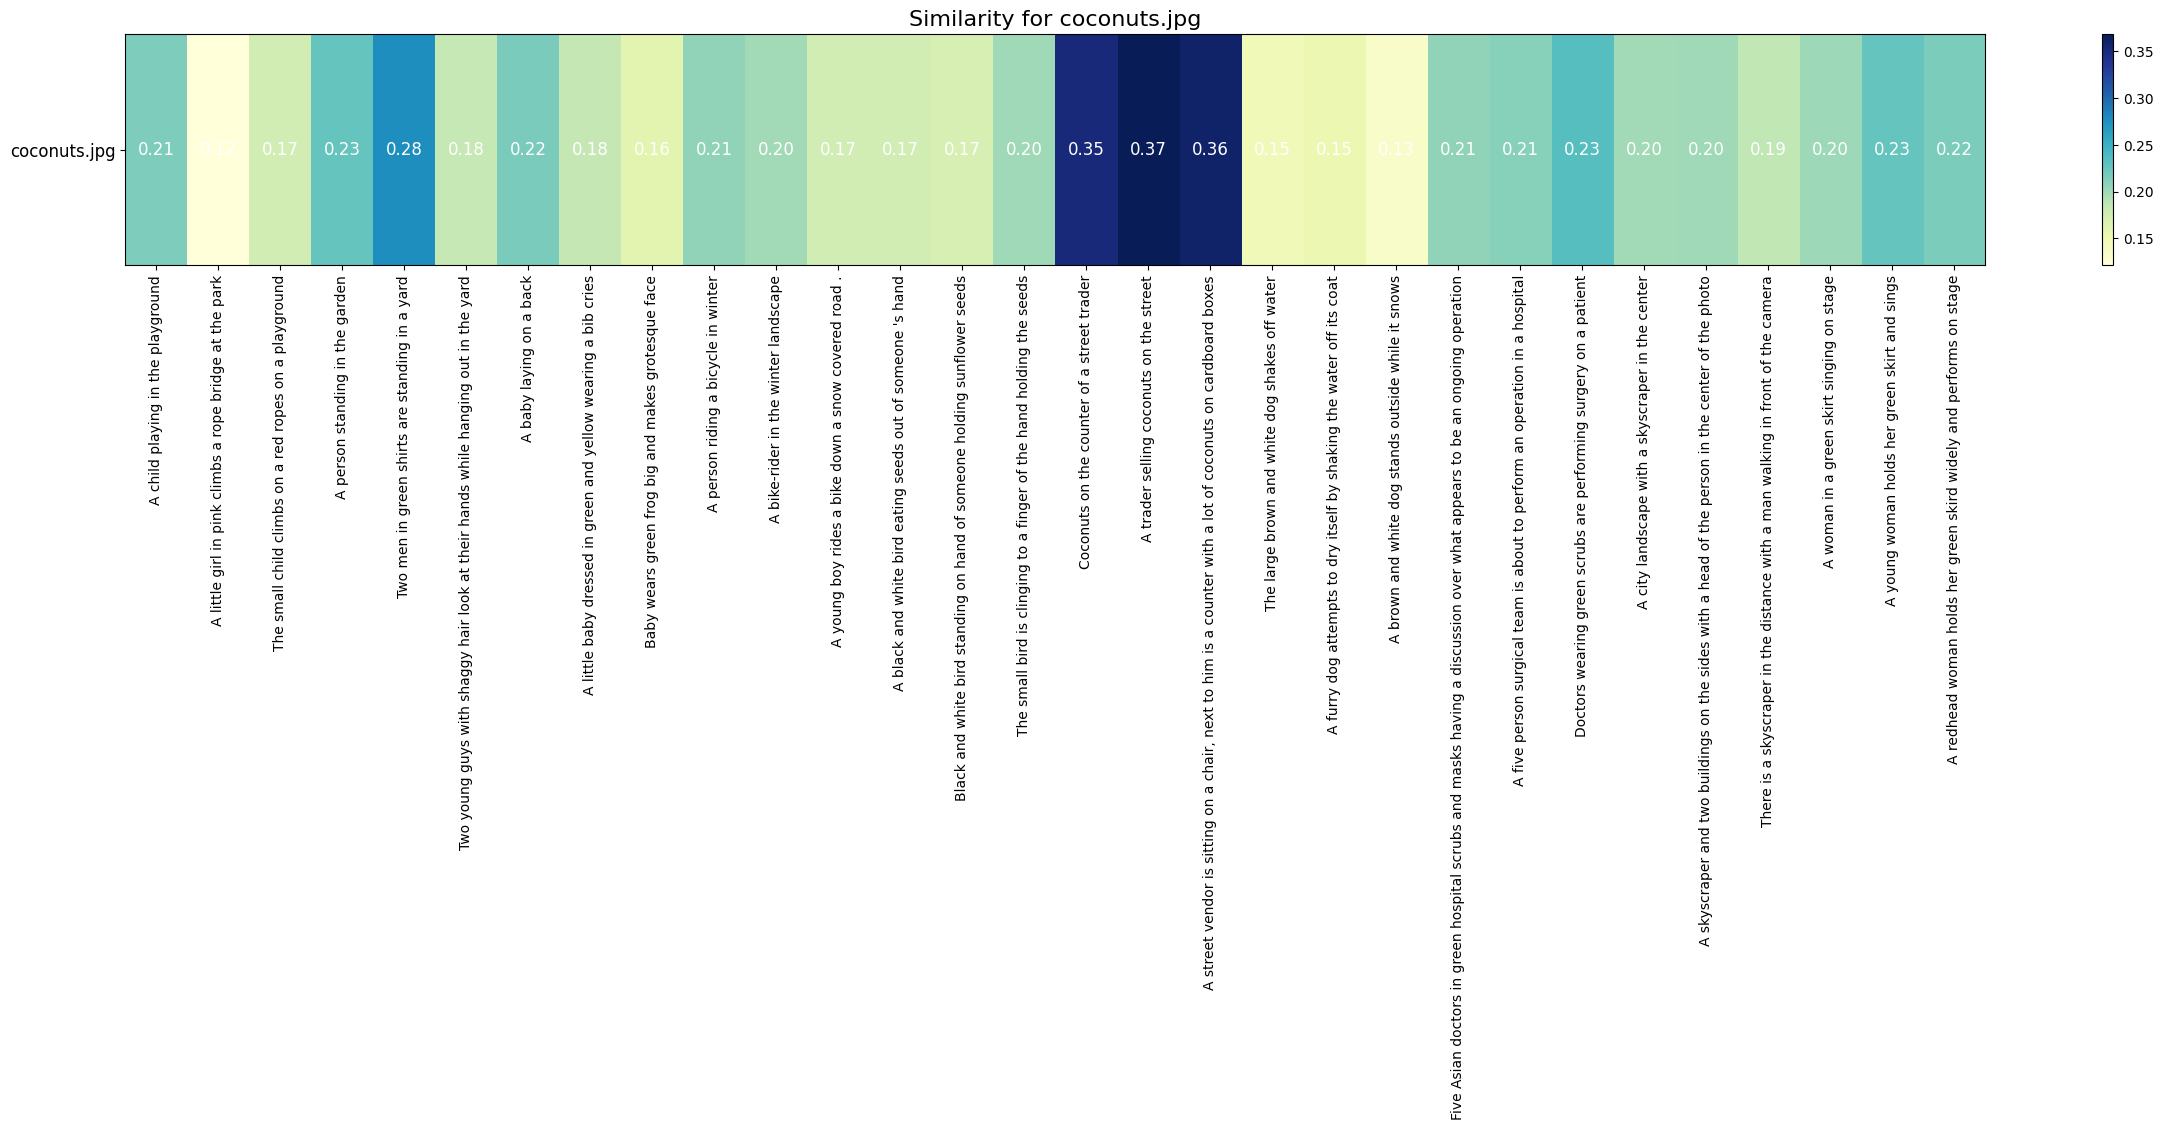

/tmp/ipykernel_215/1769272334.py:30: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all axes decorations.
  plt.tight_layout()


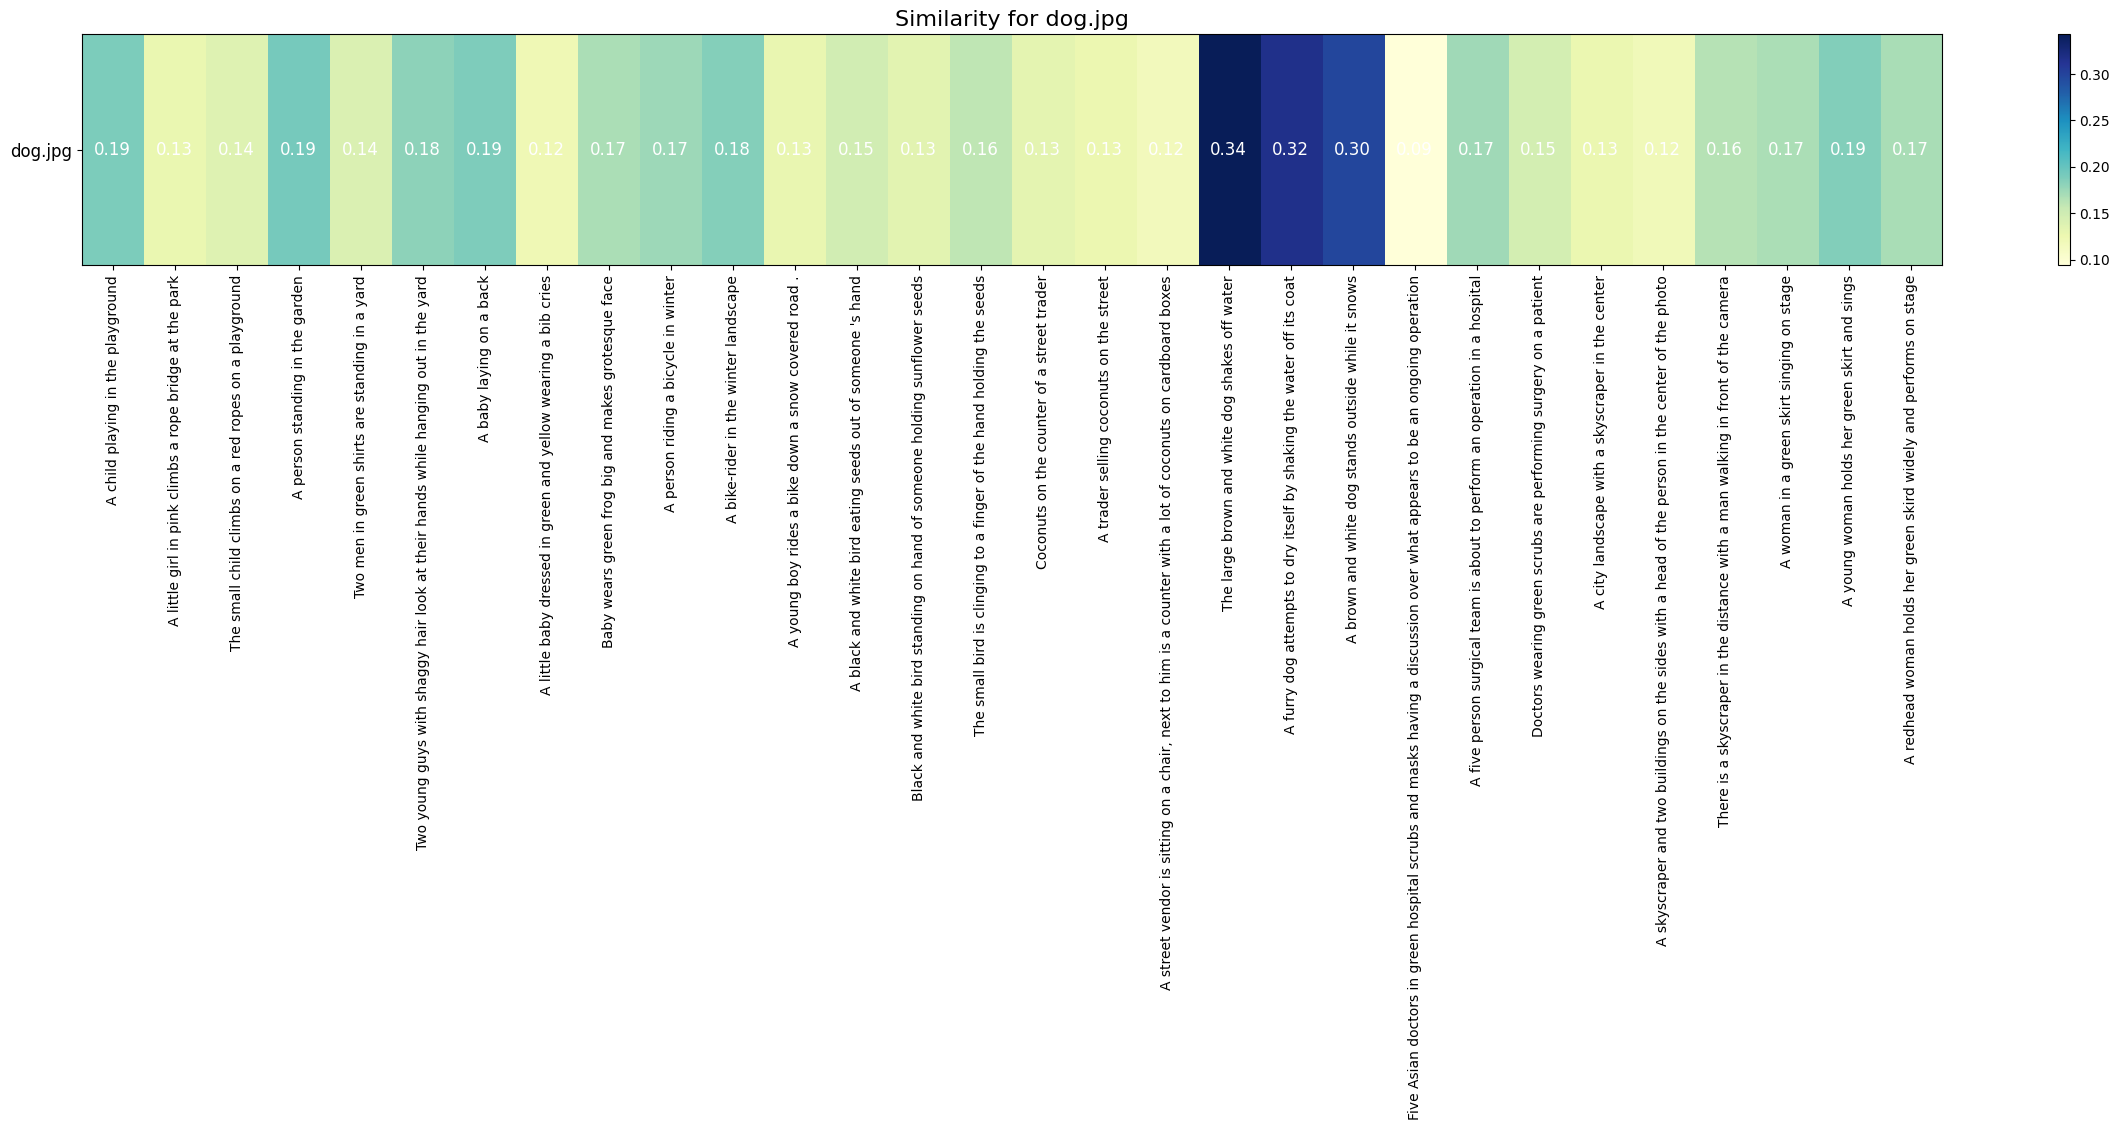

/tmp/ipykernel_215/1769272334.py:30: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all axes decorations.
  plt.tight_layout()


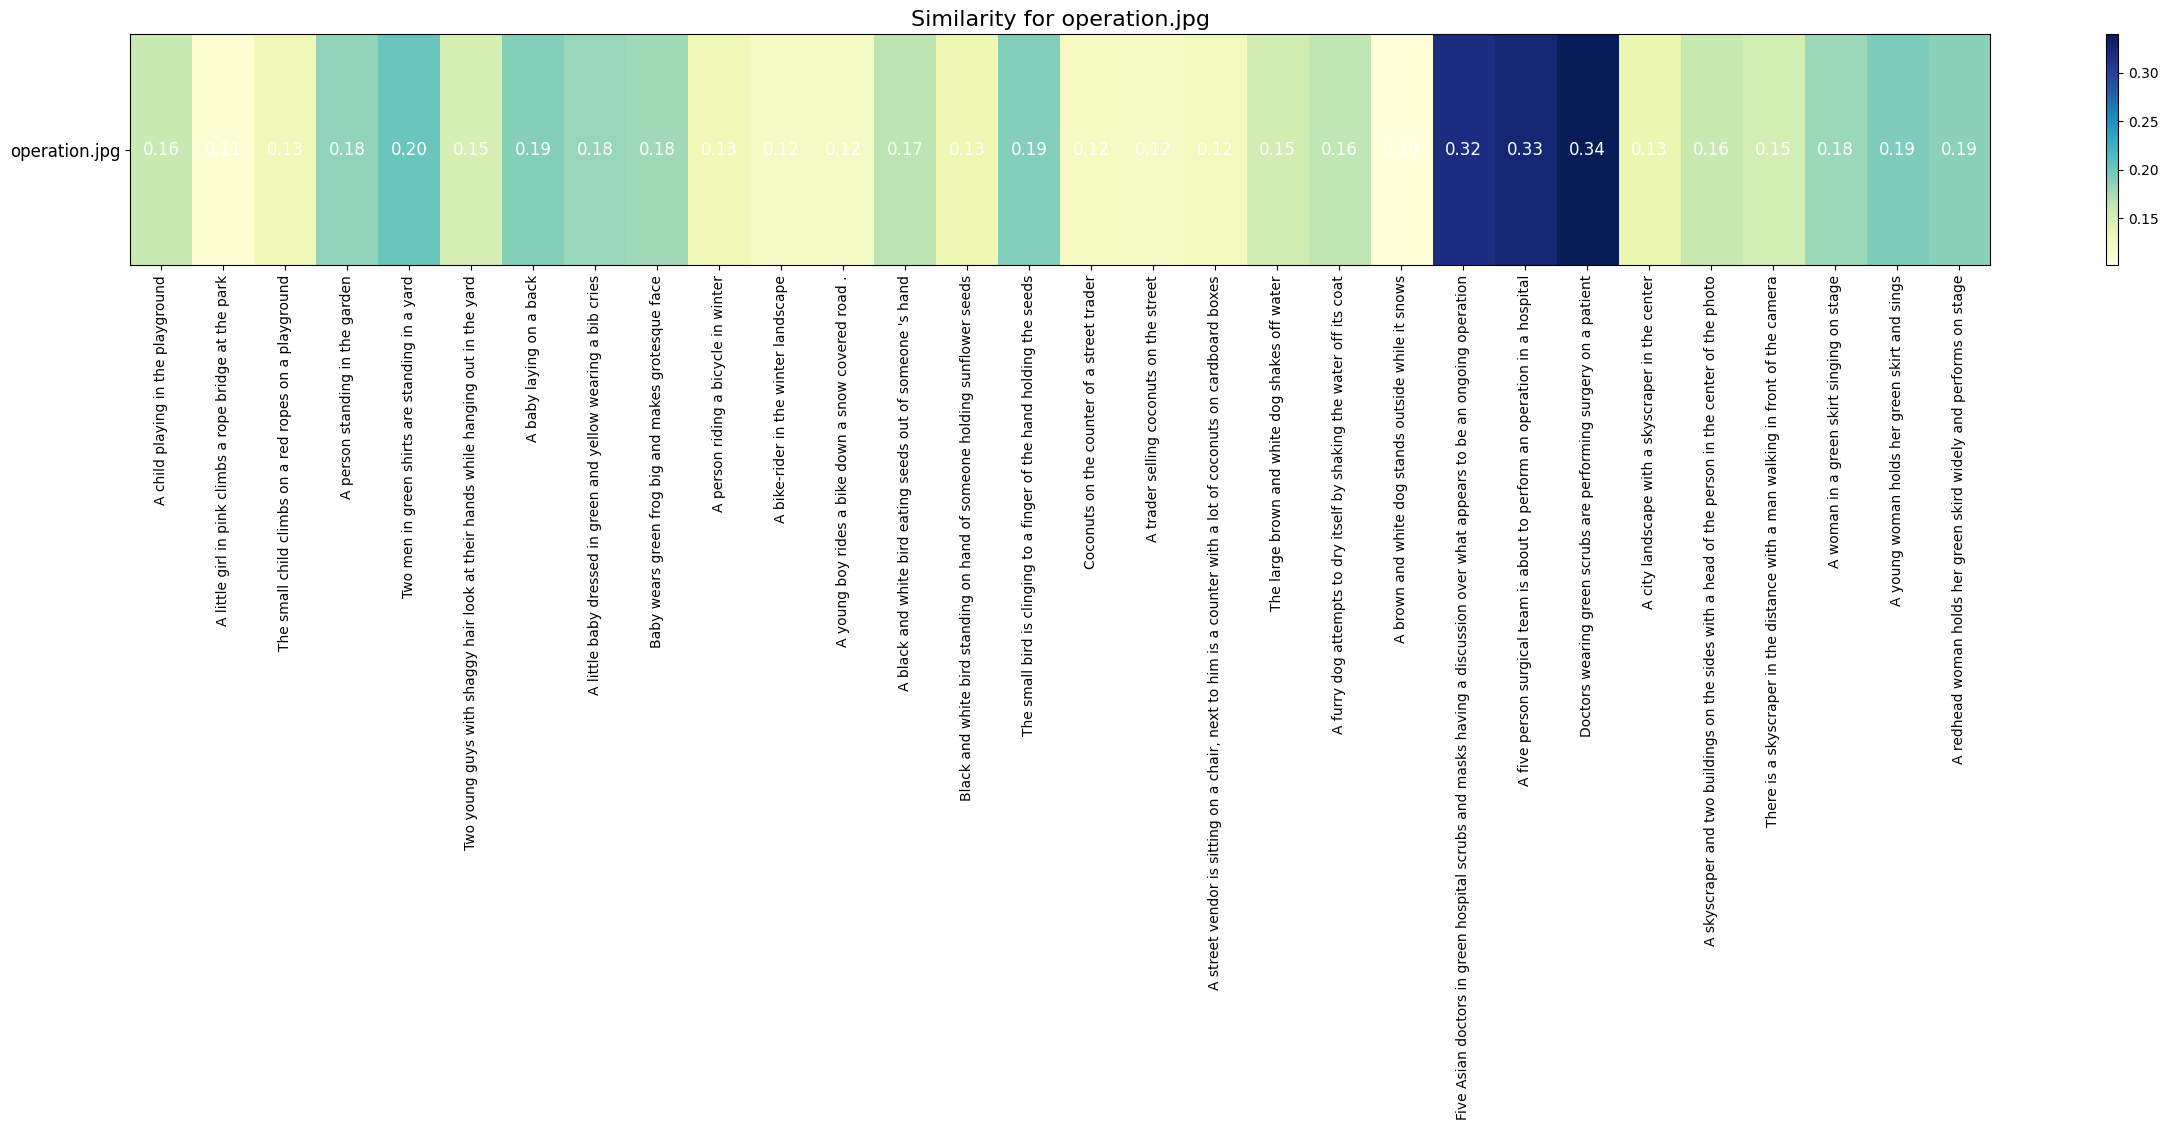

/tmp/ipykernel_215/1769272334.py:30: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all axes decorations.
  plt.tight_layout()


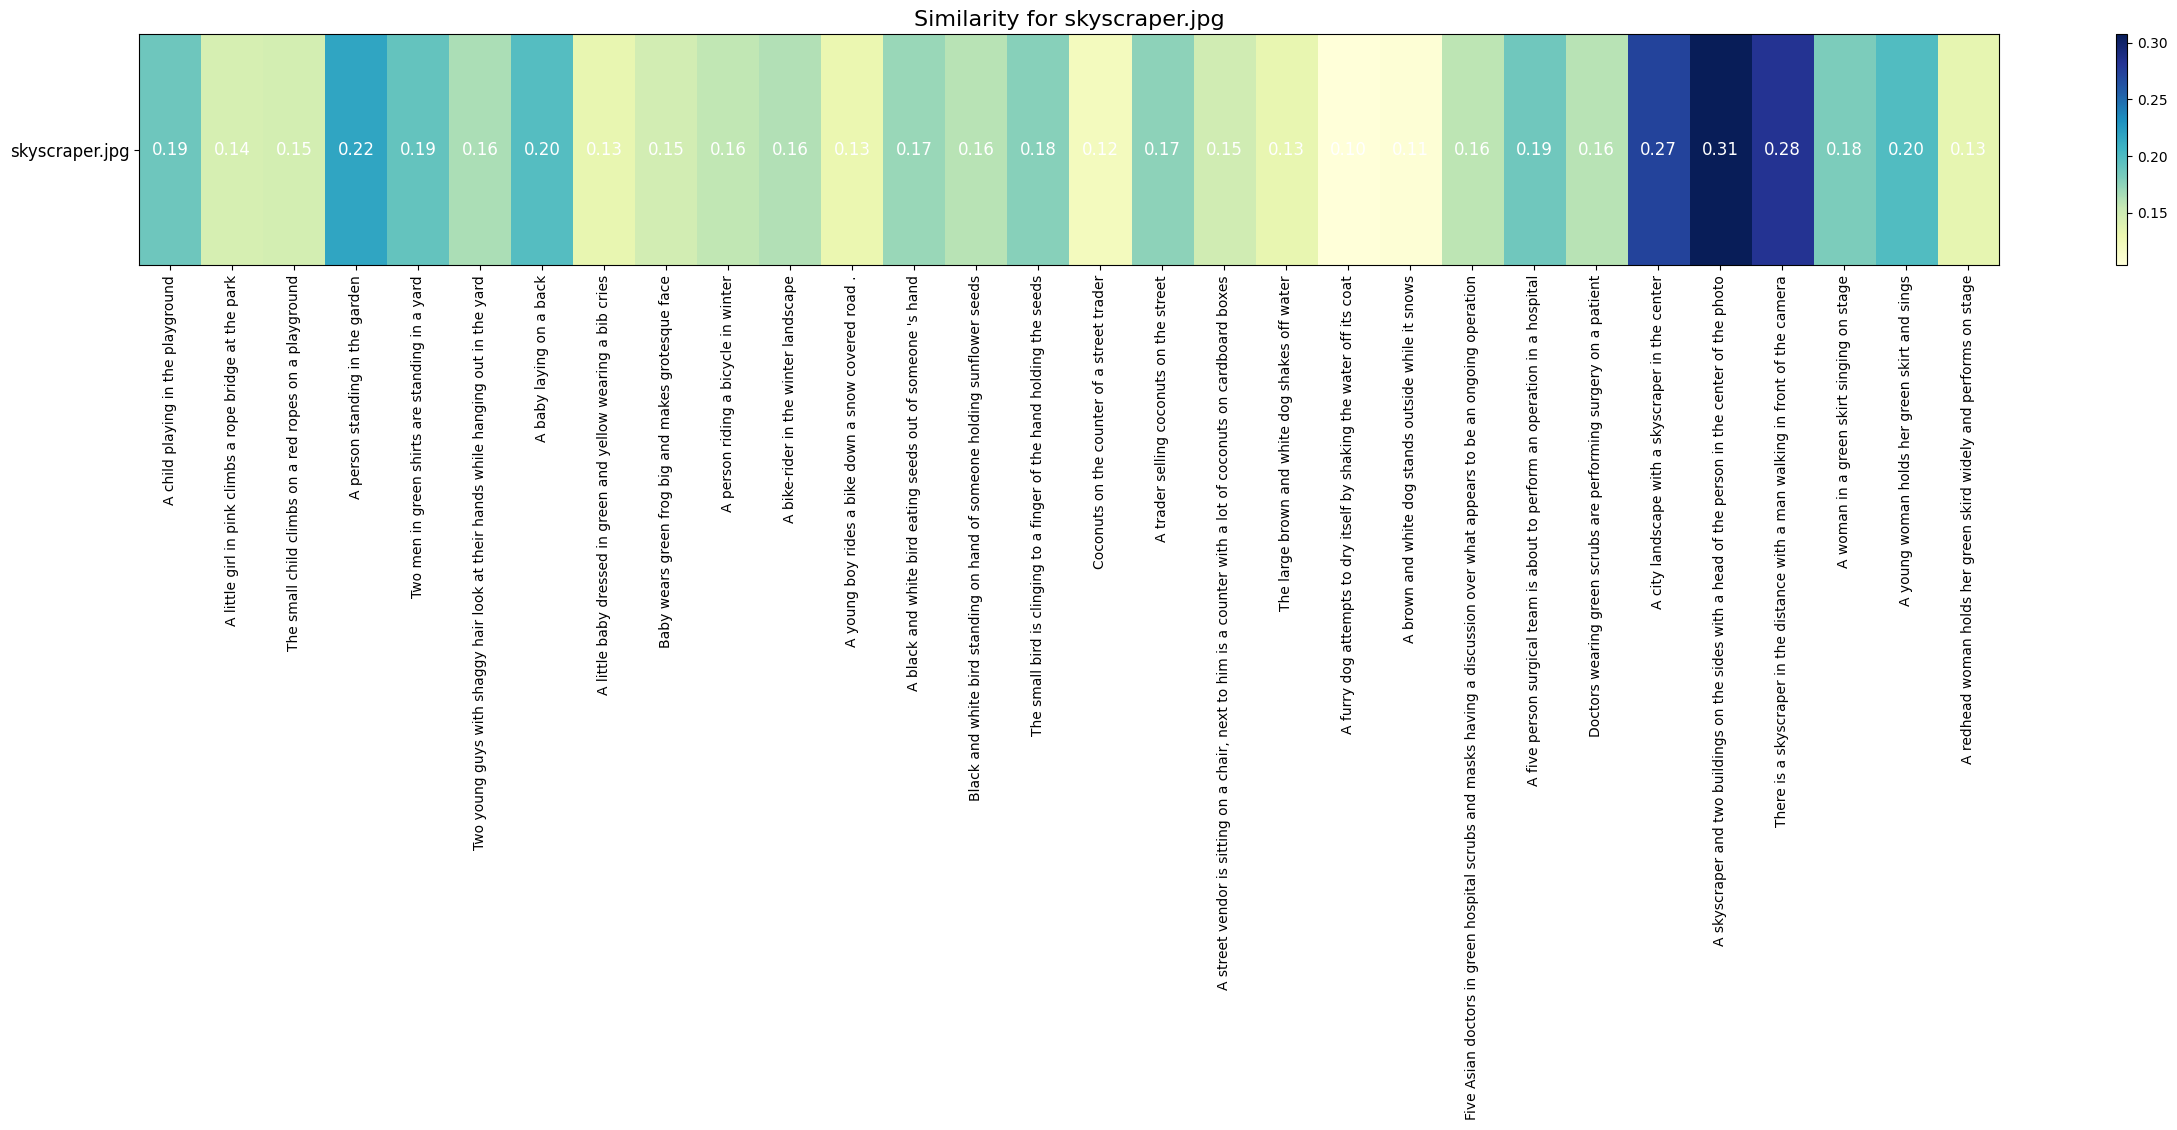

/tmp/ipykernel_215/1769272334.py:30: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all axes decorations.
  plt.tight_layout()


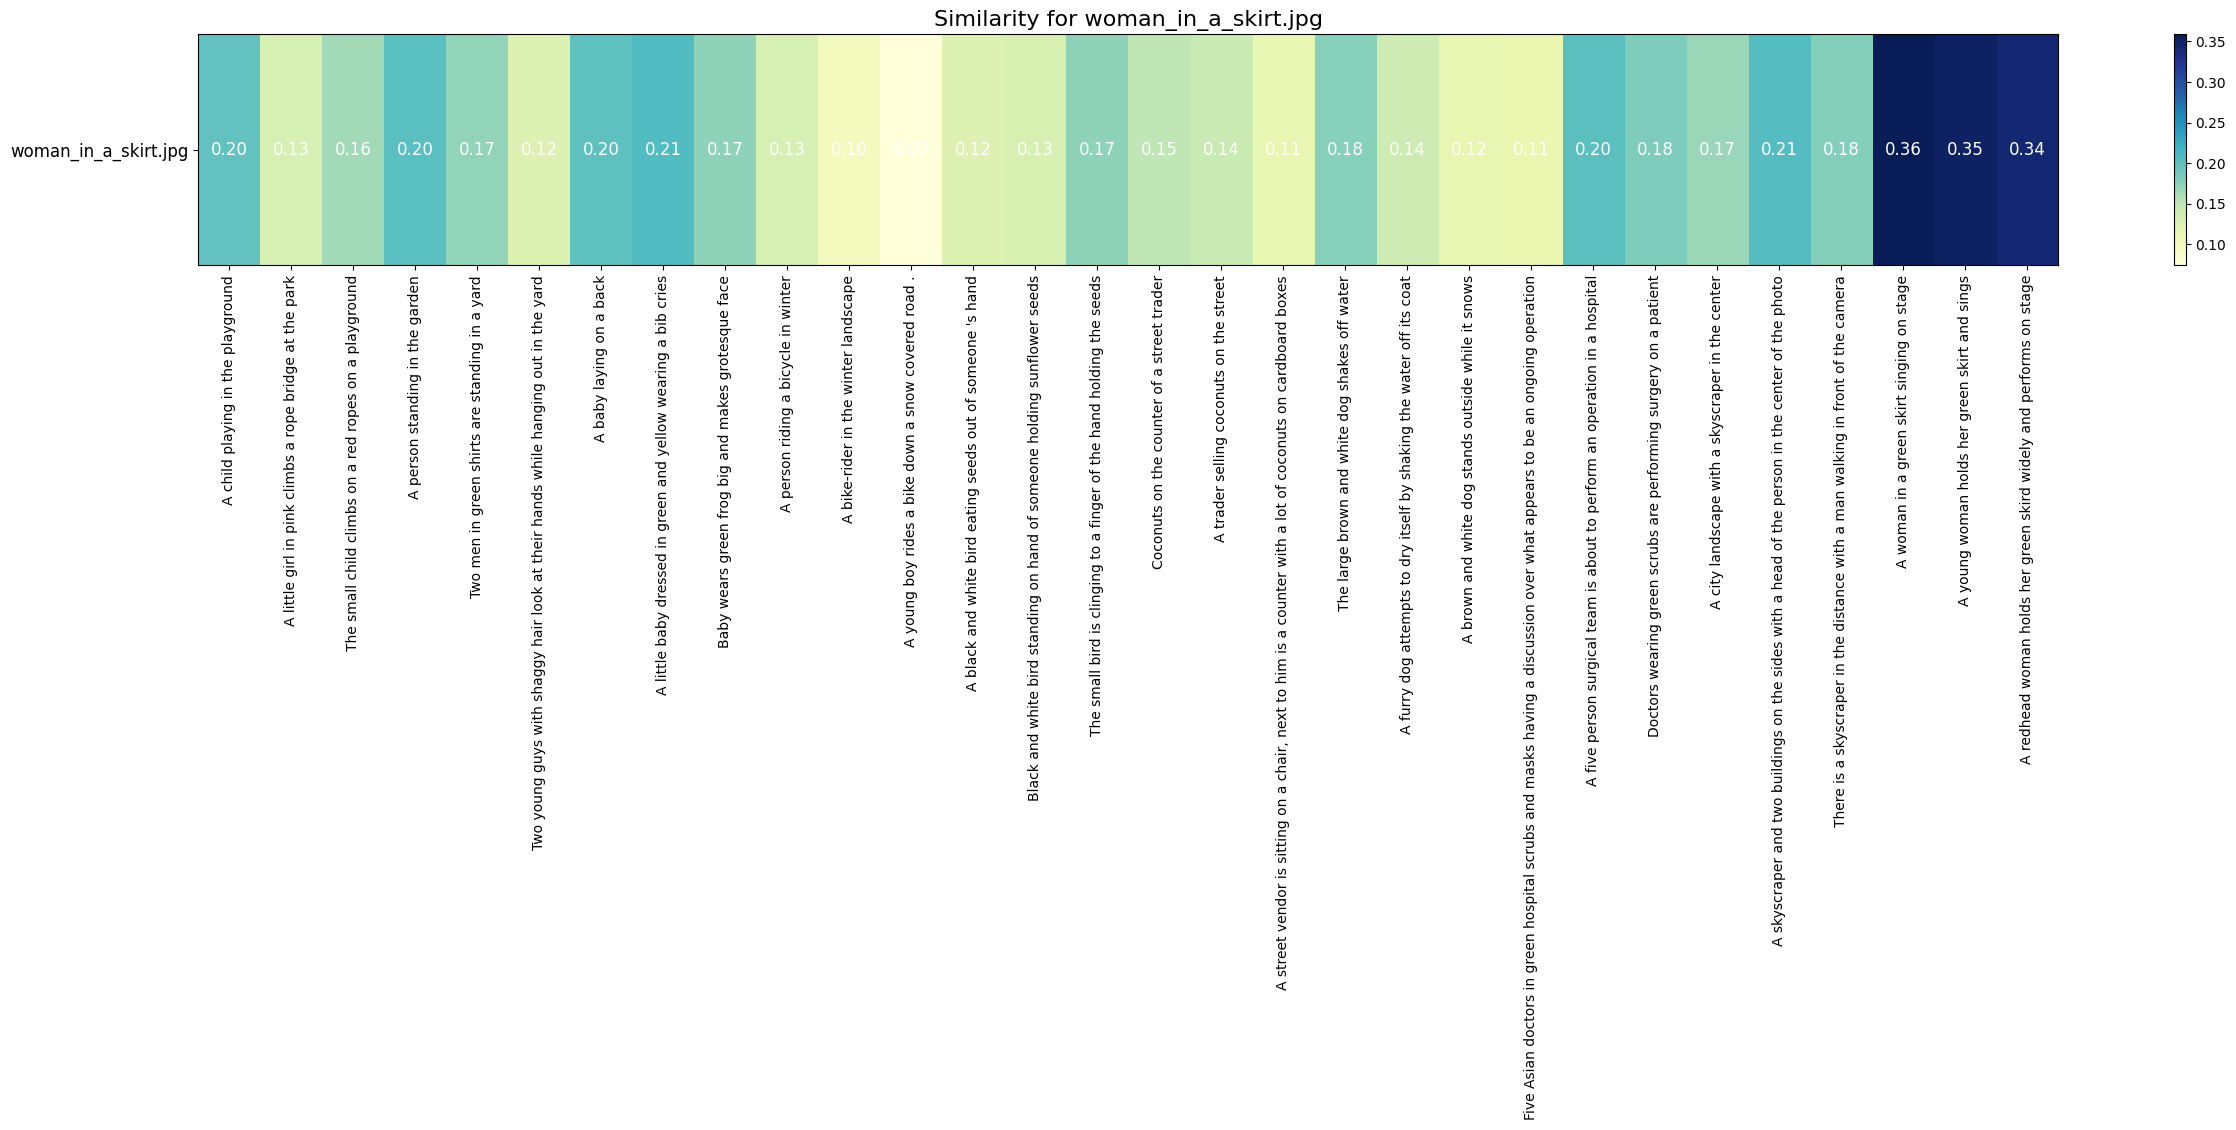

In [6]:
# Для каждого изображения строим heatmap
for idx, image_path in enumerate(image_paths):
    image_name = os.path.basename(image_path)
    texts = text_descriptions

    # Получение эмбеддинга изображения
    image = preprocess(Image.open(image_path)).unsqueeze(0).to(device)
    with torch.no_grad():
        image_feature = model.encode_image(image)
        image_feature /= image_feature.norm(dim=-1, keepdim=True)

    # Эмбеддинги текстов
    text_tokens = clip.tokenize(texts).to(device)
    with torch.no_grad():
        text_features = model.encode_text(text_tokens)
        text_features /= text_features.norm(dim=-1, keepdim=True)

    # Схожесть:
    similarity = (image_feature @ text_features.T).cpu().numpy()

    # Визуализация
    plt.figure(figsize=(30, 3))
    plt.title(f"Similarity for {image_name}", fontsize=16)
    plt.imshow(similarity, cmap="YlGnBu", aspect="auto")
    plt.yticks([0], [image_name], fontsize=12)
    plt.xticks(ticks=np.arange(len(texts)), labels=texts, rotation=90, ha='center')
    for i, score in enumerate(similarity[0]):
        plt.text(i, 0, f"{score:.2f}", ha='center', va='center', color='white', fontsize=12, clip_on=True)
    plt.colorbar()
    plt.tight_layout()
    plt.show()

В ходе эксперимента использовалась предобученная модель OpenAI CLIP с визуальным энкодером ViT-B/32. Для сопоставления изображений и текстов применялось косинусное сходство между эмбеддингами, полученными из визуального и текстового энкодеров. Текстовые описания (по три на изображение) были токенизированы с помощью функции clip.tokenize, а эмбеддинги нормированы по L2-норме перед сравнением. 

Для каждого изображения было задано три текстовых описания, относящихся к одной и той же картинке. Полученные значения сходства в основном находились в диапазоне от 0.27 до 0.36, что указывает на умеренную степень соответствия между визуальным содержанием изображения и его описанием.

Интересно отметить, что различия между значениями сходства для трёх описаний одного изображения оказались минимальными, что может свидетельствовать о стабильности восприятия модели: она интерпретирует все три текста как примерно одинаково релевантные данному изображению, несмотря на вариации в формулировках. Это также подтверждает способность модели CLIP улавливать общее смысловое содержание, а не лишь точные ключевые слова.

Тем не менее, близость значений также может указывать на ограниченную чувствительность к нюансам в текстах. Для более глубокого анализа можно было бы провести сопоставление одного изображения с нерелевантными описаниями других изображений — чтобы оценить контраст и убедиться, что CLIP действительно различает "свои" и "чужие" описания.

Отдельно можно отметить, что более короткие описания дают более низкие значения сходства. Например, в случае с изображением младенца описание “A baby laying on a back” дало заметно более низкое значение (около 0.22), чем более детализированные альтернативы. Это может быть связано с тем, что краткие тексты содержат меньше информации, что затрудняет точное сопоставление с визуальными признаками на изображении. Таким образом, длина и конкретика текста влияют на эффективность семантического сопоставления в CLIP. Но чтобы утверждать это точно, понадобится более расширенная проверка на более крупном датасете изображений и описаний.

<a style='text-decoration:none;line-height:16px;display:flex;color:#5B5B62;padding:10px;justify-content:end;' href='https://deepnote.com?utm_source=created-in-deepnote-cell&projectId=5b0ef6a4-40ad-4fc7-9768-0b5de8bb5cf8' target="_blank">
 </img>
Created in <span style='font-weight:600;margin-left:4px;'>Deepnote</span></a>